In [167]:
import pandas as pd
import importlib
from scipy.stats import chisquare
from scipy.stats import chi2_contingency
import numpy as np

import plotly.express as px
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import irina.utility_functions as uf

In [2]:
importlib.reload(uf)

<module 'Irina.utility_functions' from '/Users/irinavorobeva/PycharmProjects/geoTopics/Irina/utility_functions.py'>

In [21]:
df_global = pd.read_csv(uf.PATH+"df_global_comparison_yearly.csv").drop_duplicates()

In [22]:
df_global

,subfield_id,counts_all,counts_individual,counts_collab,probability_all,probability_individual,probability_collab,counts_individual_pct,counts_collab_pct,year
0,1100,641,621,20.0,0.003229,0.003219,0.003595,96.879875,3.120125,1970
1,1102,833,807,26.0,0.004196,0.004183,0.004674,96.878752,3.121248,1970
2,1103,1500,1463,37.0,0.007557,0.007583,0.006651,97.533333,2.466667,1970
3,1104,427,410,17.0,0.002151,0.002125,0.003056,96.018735,3.981265,1970
4,1105,2068,1999,69.0,0.010418,0.010361,0.012403,96.663443,3.336557,1970
...,...,...,...,...,...,...,...,...,...,...
14581,3609,6589,6066,523.0,0.001393,0.001533,0.000677,92.062528,7.937472,2023
14582,3611,3130,2782,348.0,0.000662,0.000703,0.000451,88.881789,11.118211,2023
14583,3612,8603,7834,769.0,0.001819,0.001980,0.000996,91.061258,8.938742,2023
14584,3614,5430,4547,883.0,0.001148,0.001149,0.001143,83.738490,16.261510,2023


In [23]:
start_year = 1970
end_year = 2023

In [24]:
df_global_topics = (
    df_global
    .merge(uf.df_topics[["subfield_id", "subfield_name", "field_name", "domain_name"]].drop_duplicates(),
           on="subfield_id", how="left")
    .assign(
        probability_individual_change=lambda df: df.groupby("subfield_id").probability_individual.transform(lambda x: (x - x.iloc[0])),
        probability_individual_relative=lambda df: df.groupby("subfield_id").probability_individual.transform(lambda x: (x / x.iloc[0])),
    )
    # .query("subfield_id in @subfields_list")
)

In [25]:
fig = px.line((
        df_global
        [["year", "counts_collab", "counts_all"]]
        .groupby("year", as_index=False)
        .sum()
        .assign(loss_percent=lambda df: df.counts_collab / df.counts_all * 100)
    ),
    x="year", y="loss_percent", labels={"loss_percent": "Articles written in collaborations (%)", "year": "Year"})
fig.show()
# fig.write_image("../images/collaboration_percent.png", width=1200, height=600, scale=2)

# Loss by subfields

In [27]:
df_loss = (
    df_global
    .pivot(index="year", columns="subfield_id", values="counts_collab_pct")
)

In [52]:
fig = uf.plotly_heatmap(
    df_loss,
    x_labels=df_loss.columns.astype(str),
    y_labels=df_loss.index,
    x_type="subfield",
    z_min=0, z_max=50,
    line_height=10,
    colorscale="non-symmetric",
    title="Global collaboration losses by subfields (%)"
)
fig.show()
# fig.write_image("../images/global_collaboration_losses_all_1970_2023.png",
#                 width=1200, height=600, scale=2)

In [169]:
# year = 2023
# counts = df_loss.loc[year].dropna().values
# expected = np.ones_like(counts) * counts.mean()
#
# res = chisquare(counts, expected)
# # res.statistic
# print("p-value (collaboration shares are uniform by subfields):", res.pvalue)

In [173]:
year = 2023

counts = df_global.query("year == @year").set_index("subfield_id")[["counts_individual", "counts_collab"]].dropna()

chi2, p, dof, expected = chi2_contingency(counts)

print("Hypothesis: collaborations are independent of subfields, p-value =", p)
# chi2, p

Hypothesis: collaborations are independent of subfields, p-value = 0.0


In [182]:
counts = df_global_topics[["field_name", "counts_individual", "counts_collab"]].groupby("field_name").sum().values
chi2, p, dof, expected = chi2_contingency(counts)

print("Hypothesis: collaborations are independent of fields, p-value =", p)

Hypothesis: collaborations are independent of fields, p-value = 0.0


In [183]:
counts = df_global_topics[["domain_name", "counts_individual", "counts_collab"]].groupby("domain_name").sum().values
chi2, p, dof, expected = chi2_contingency(counts)

print("Hypothesis: collaborations are independent of domains, p-value =", p)

Hypothesis: collaborations are independent of domains, p-value = 0.0


In [146]:
year = 2023

fig = px.box(
    df_global_topics.query("year == @year"),
    x="domain_name",           # each domain = one box
    y="counts_collab_pct",       # values to summarize
    points="all",              # optional: show all points
    color="domain_name",       # color boxes by domain
    height=600,
    # title=f"Distribution of counts_loss_pct by domain in {year}",
    hover_data=["domain_name", "counts_collab_pct", "subfield_name"],
)

fig.update_layout(
    yaxis_title="Counts loss (%)",
    xaxis_title="Domain",
    showlegend=False
)

fig.show()
# fig.write_image("../images/global_collaboration_losses_by_domain_2023.png",
#                 width=1200, height=600, scale=2)

In [49]:
year = 2023
domain_name = "Social Sciences"

fig = px.box(
    df_global_topics.query("year == @year").query(f"domain_name == @domain_name"),
    x="field_name",           # each domain = one box
    y="counts_collab_pct",       # values to summarize
    points="all",              # optional: show all points
    color="field_name",       # color boxes by domain
    height=600,
    # title=f"Distribution of counts_loss_pct by field in {year} in {domain_name}",
    hover_data=["field_name", "counts_collab_pct", "subfield_name"],
)

fig.update_layout(
    yaxis_title="Collab share (%)",
    xaxis_title="Domain",
    showlegend=False
)

fig.show()
# fig.write_image("../images/global_collaboration_losses_social_by_field_2023.png",
#                 width=1200, height=600, scale=2)

# Loss by countries

In [210]:
importlib.reload(uf)

<module 'Irina.utility_functions' from '/Users/irinavorobeva/PycharmProjects/geoTopics/Irina/utility_functions.py'>

In [213]:
# uf.get_counts_year(year, df_global)

In [216]:
uf.get_counts_year(year, df_global).set_index("alpha-2")[["counts_indiv", "counts_collab"]]

,counts_indiv,counts_collab
alpha-2,,
AD,8.0,26.0
AE,5170.0,9863.0
AF,529.0,400.0
AG,115.0,370.0
AL,969.0,425.0
...,...,...
WS,12.0,34.0
YE,949.0,1318.0
ZA,19694.0,12556.0


In [212]:
year = 2023

counts = uf.get_counts_year(year, df_global).set_index("alpha-2")[["counts_indiv", "counts_collab"]].dropna()

chi2, p, dof, expected = chi2_contingency(counts)

print("Hypothesis: collaborations are independent of countries, p-value =", p)
# chi2, p

Hypothesis: collaborations are independent of countries, p-value = 0.0


In [201]:
years_all = range(start_year, end_year + 1)
df_country_shares_list = []
for year_loop in years_all:
    df_country_shares_list.append(uf.get_losses_year(year_loop, df_global).assign(year=str(year_loop)))
df_country_shares=pd.concat(df_country_shares_list)

In [202]:
years_list = ["1970", "1980", "1990", "2000", "2010", "2023"]
df_country_shares_year_list = df_country_shares.query("year == @years_list")

In [203]:
fig = px.box(
    df_country_shares_year_list,
    x="year",           # each domain = one box
    y="counts_collab_pct",       # values to summarize
    points="all",              # optional: show all points
    color="year",       # color boxes by domain
    height=600,
    title=f"Distribution of collaboration % in countries",
    hover_data=["name", "counts_collab_pct", "region", "alpha-2"],
)

fig.update_layout(
    yaxis_title="Counts collaboration (%)",
    xaxis_title="Year",
    showlegend=False
)

fig.show()
# fig.write_image("../images/global_collaboration_losses_by_year.png",
#                 width=1200, height=600, scale=2)

In [204]:
year = "2023"
fig = px.box(
    df_country_shares.query("year == @year"),
    x="region",           # each domain = one box
    y="counts_collab_pct",       # values to summarize
    points="all",              # optional: show all points
    color="region",       # color boxes by domain
    height=600,
    title=f"Distribution of collaboration % by region in {year}",
    hover_data=["name", "counts_collab_pct", "region"],
)

fig.update_layout(
    yaxis_title="Counts collaboration (%)",
    xaxis_title="region",
    showlegend=False
)

fig.show()
# fig.write_image("../images/global_collaboration_losses_by_region_{year}.png",
#                 width=1200, height=600, scale=2)

In [205]:
year = "2023"

counts = df_country_shares.query("year == @year").counts_collab_pct.dropna().values
expected = np.ones_like(counts) * counts.mean()
res = chisquare(counts, expected)
# res.statistic
print("p-value (collaboration shares are uniform by countries):", res.pvalue)

p-value (collaboration shares are uniform by countries): 2.32293330657837e-205


In [206]:
country_list = ["CN", "IN", "BR", "RU", "ID", "US", "CH", "FR"]
px.line(
    df_country_shares.rename(columns={"alpha-2": "country"}).query("country == @country_list"),
    x="year",
    y="counts_collab_pct",
    color="name",
    title="Collaboration shares, %"
)

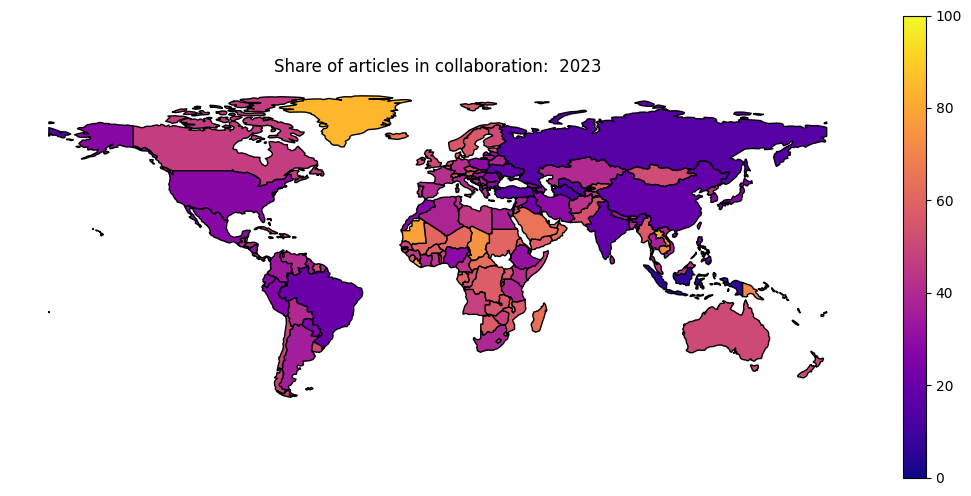

In [215]:
importlib.reload(uf)
year = 2023
df_country_shares_year = get_losses_year(year)

fig, ax = uf.plot_map_continuous(df_country_shares_year, "counts_collab_pct", title="Share of articles in collaboration: ", range=(0, 100), year=year)
# plt.savefig(f"../images/map_collab_{year}.png")

In [208]:
df_country_shares_year.sort_values("counts_collab_pct", ascending=False)

,counts_indiv_pct,counts_collab_pct,alpha-2,alpha-3,name,region,sub-region
165,0.000000,100.000000,MP,MNP,Northern Mariana Islands,Oceania,Micronesia
12,2.941176,97.058824,AW,ABW,Aruba,Americas,Latin America and the Caribbean
24,5.000000,95.000000,BM,BMU,Bermuda,Americas,Northern America
4,6.250000,93.750000,AS,ASM,American Samoa,Oceania,Polynesia
72,6.896552,93.103448,FK,FLK,Falkland Islands (Malvinas),Americas,Latin America and the Caribbean
...,...,...,...,...,...,...,...
238,84.313374,15.686626,UZ,UZB,Uzbekistan,Asia,Central Asia
183,85.135869,14.864131,RU,RUS,Russian Federation,Europe,Eastern Europe
228,86.428571,13.571429,TM,TKM,Turkmenistan,Asia,Central Asia
104,94.428224,5.571776,ID,IDN,Indonesia,Asia,South-eastern Asia


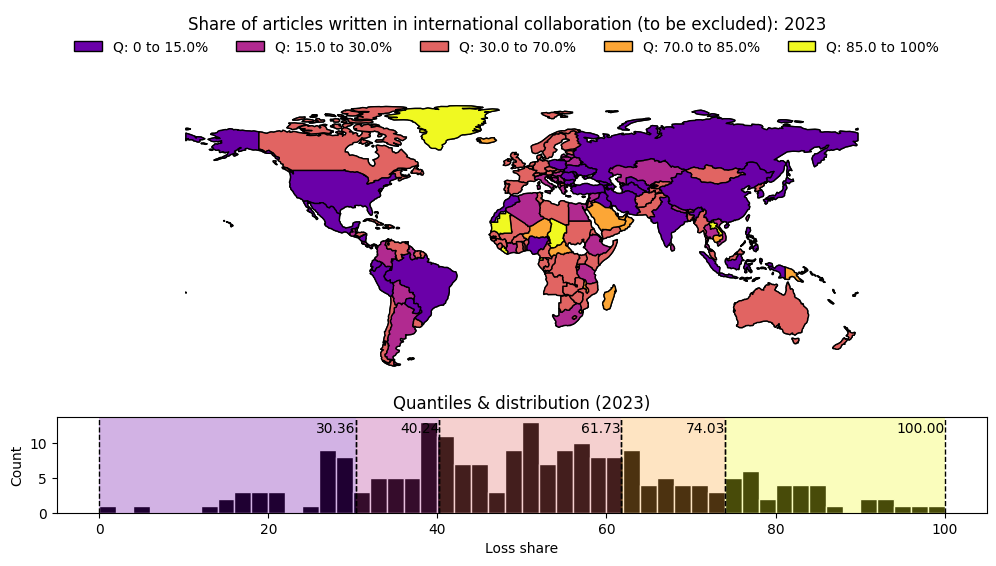

In [209]:
importlib.reload(uf)

year = 2023
df_country_shares_year = get_losses_year(year)

quantiles_pct = [0, 0.15, 0.3, 0.7, 0.85, 1]

df_map, ax_map, ax_hist = uf.plot_map_distribution(df_country_shares_year, "counts_collab_pct", quantiles_pct, year=year, map_title="Share of articles written in international collaboration (to be excluded)", histogram_title="Quantiles & distribution", hist_range=(0, 100))

plt.savefig(f"../images/loss_collab_{year}.png")

In [ ]:
# importlib.reload(uf)
#
# def animate_continuous(year):
#     df_year = get_losses_year(year)
#     _, _ = uf.plot_map_continuous(df_year, "counts_collab_pct", title="Share of articles in collaboration: ",
#                                   range=(0, 100), fig=fig, ax=ax, year=year)


In [147]:
# years = range(1970, 2024)
#
# fig, ax = plt.subplots(figsize=(12,6))
#
# animation = False
#
# anim = FuncAnimation(fig, animate_continuous, frames=years, interval=1000, blit=False)
#
# # Save as GIF
# # anim.save('map_animation.gif', writer='pillow', dpi=150)
#
# # Or save as MP4
# anim.save('../animations/loss_collaborations_continuous_1970_2023.mp4', writer='ffmpeg', dpi=150)